# e13b — Is the answer-side mask channel decode-realizable? (decision-token diagnostic)

**2026-07-21 · gate experiment for decode-time mask injection** (design:
`e11_decode_time_injection_design.md`; instrument: `scripts/diag_injection_ablation.py`;
background: `findings_for_gegr.md` §4/§6.4). Cluster jobs `7159042`, `7159105`, `7159115`;
code at branch `e13_nav_pe` (`cf10bb1` + benchmark task).

**Question.** The leak-trained RPE-mask circuit scores **0.865** decision accuracy when
answer-side node mentions carry their mask rows (`train_style`) — with-edges-level, but
measured under wiring that real generation does not have. Decode-time injection could
legally restore *part* of that wiring: a mention's rows once its span is **complete**
(keys everywhere, queries only at the final token). The unmeasured gap was the
**mid-span query enrichment** that decode can never provide. This notebook measures it.


## Conditions (teacher-forced; identical weights/tokens/seed; only the wiring varies)

| condition | answer-mention wiring | decode-realizable? |
|---|---|---|
| `no_injection` | none anywhere (plain LLM) | — |
| `prompt_only` | none (prompt mentions only) | **what generation has today** |
| `decode_style` | keys: full span; queries: final token only | **yes** (design-note §3 rule) |
| `decode_trail` | decode_style + completed id rides inter-mention query rows | yes (adds "current location") |
| `train_style` | full spans, both roles | no — needs the label (leak) |

Graded ONLY on **decision tokens** (first token of a node's first answer mention,
n=519 over 100 val conversations) — completion/repeat positions are ~0.99 everywhere.
Implementation: asymmetric query/key maps in `build_structural_mask`
(`key_injection_maps=`), unit-tested in `tests/test_decode_style_mask.py`.

**Pre-registered reading** (stated before results, see conversation log):
`decode_style ≈ train_style` ⇒ decode-time injection can recover the measured headroom
→ build it. `decode_style ≈ prompt_only` ⇒ the headroom lives in non-realizable
mid-span enrichment → don't build.


In [1]:
import json, pathlib
import pandas as pd

BASE = pathlib.Path("../outputs/diag_decode_style")
CHECKPOINTS = {          # label -> (json, free-generation accuracy, W&B run)
    "leaky RPE mask":      ("e10_integ_rpe__no_edge_list_tyvhwlmx.json",       0.14, "tyvhwlmx"),
    "leak-free RPE mask":  ("e11_integ_rpe_noedges_promptonly_22lq43i6.json",  0.48, "22lq43i6"),
    "leaky param-free":    ("rv_gmask_noedges_ror8gtet.json",                  0.13, "ror8gtet"),
    "with-edges RPE mask": ("e10_integ_rpe__with_edge_list_wo83xg96.json",     0.95, "wo83xg96"),
}
CONDITIONS = ["no_injection", "prompt_only", "decode_style", "decode_trail", "train_style"]

rows = []
for label, (fname, gen_acc, run) in CHECKPOINTS.items():
    path = BASE / fname
    if not path.exists():
        print(f"[missing] {fname} — skipped"); continue
    d = json.load(open(path))
    for cond in CONDITIONS:
        m = d["conditions"][cond]["decision"]
        rows.append({"checkpoint": label, "condition": cond, "acc": m["acc"],
                     "nll": m["mean_nll"], "n": m["n"]})
df = pd.DataFrame(rows)
ckpt_order = [l for l in CHECKPOINTS if (BASE / CHECKPOINTS[l][0]).exists()]


In [2]:
acc = df.pivot(index="condition", columns="checkpoint", values="acc").loc[CONDITIONS, ckpt_order]
nll = df.pivot(index="condition", columns="checkpoint", values="nll").loc[CONDITIONS, ckpt_order]
print("decision-token accuracy (n=%d per cell)" % df.n.iloc[0])
print(acc.round(4).to_string())
print()
print("decision-token NLL (nats)")
print(nll.round(3).to_string())


decision-token accuracy (n=519 per cell)
checkpoint    leaky RPE mask  leak-free RPE mask  leaky param-free  with-edges RPE mask
condition                                                                              
no_injection          0.5915              0.5645            0.5857               0.9191
prompt_only           0.6455              0.8189            0.5915               0.9210
decode_style          0.8401              0.8227            0.7091               0.9210
decode_trail          0.8382              0.8324            0.7187               0.9056
train_style           0.8651              0.8266            0.7052               0.9152

decision-token NLL (nats)
checkpoint    leaky RPE mask  leak-free RPE mask  leaky param-free  with-edges RPE mask
condition                                                                              
no_injection           2.917               2.728             1.959                0.297
prompt_only            1.993               0.714    

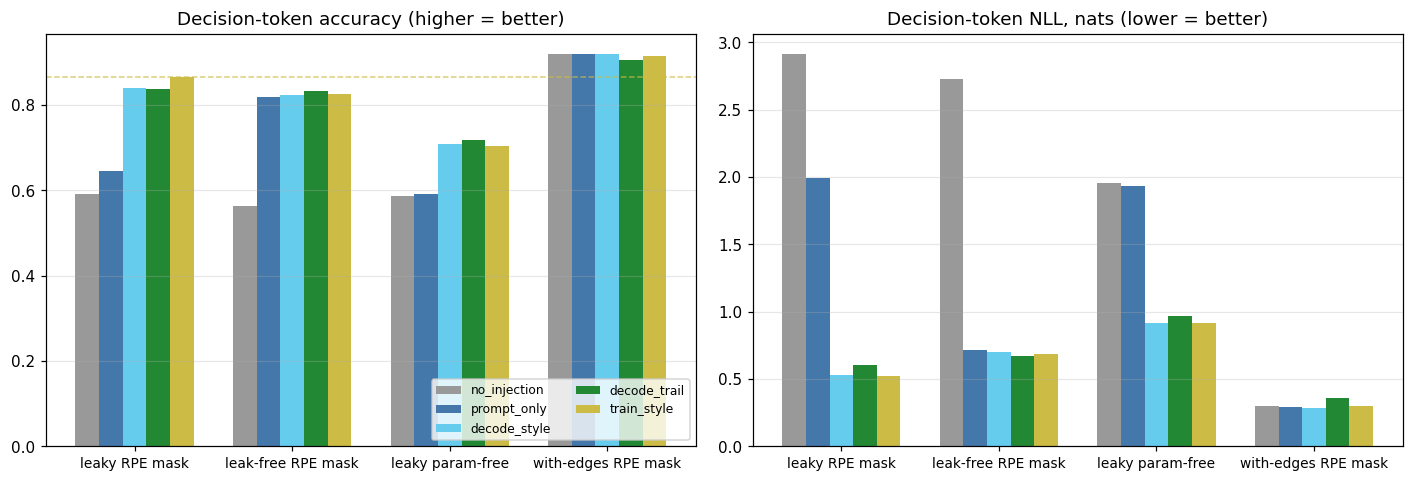

In [3]:
import matplotlib.pyplot as plt

colors = {"no_injection": "#999999", "prompt_only": "#4477AA", "decode_style": "#66CCEE",
          "decode_trail": "#228833", "train_style": "#CCBB44"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metric, title in [(axes[0], "acc", "Decision-token accuracy (higher = better)"),
                          (axes[1], "nll", "Decision-token NLL, nats (lower = better)")]:
    width = 0.15
    for ci, cond in enumerate(CONDITIONS):
        vals = [df[(df.checkpoint == l) & (df.condition == cond)][metric].item() for l in ckpt_order]
        ax.bar([x + (ci - 2) * width for x in range(len(ckpt_order))], vals, width,
               label=cond, color=colors[cond])
    ax.set_xticks(range(len(ckpt_order))); ax.set_xticklabels(ckpt_order, fontsize=9)
    ax.set_title(title); ax.grid(axis="y", alpha=0.3)
axes[0].axhline(0.8651, color="#CCBB44", ls="--", lw=1, alpha=0.7)
axes[0].legend(fontsize=8, ncol=2, loc="lower right")
fig.tight_layout()
plt.show()


In [4]:
# Compounding sanity check: teacher-forced per-decision accuracy vs actual free-run
# task accuracy. Decisions per task vary (~3-6); show acc**k bands for k=3..6.
for label in ckpt_order:
    gen = CHECKPOINTS[label][1]
    p = df[(df.checkpoint == label) & (df.condition == "prompt_only")].acc.item()
    band = ", ".join(f"p^{k}={p**k:.2f}" for k in (3, 4, 5))
    print(f"{label:22s} prompt_only p={p:.3f} -> {band}   (actual free-gen: {gen})")


leaky RPE mask         prompt_only p=0.645 -> p^3=0.27, p^4=0.17, p^5=0.11   (actual free-gen: 0.14)
leak-free RPE mask     prompt_only p=0.819 -> p^3=0.55, p^4=0.45, p^5=0.37   (actual free-gen: 0.48)
leaky param-free       prompt_only p=0.592 -> p^3=0.21, p^4=0.12, p^5=0.07   (actual free-gen: 0.13)
with-edges RPE mask    prompt_only p=0.921 -> p^3=0.78, p^4=0.72, p^5=0.66   (actual free-gen: 0.95)


## Reading the numbers

**1. The gate passes on the leaky circuit.** `decode_style` = **0.840 / 0.53 nats** vs
`train_style` 0.865 / 0.52: the decode-realizable wiring retains ~97% of the channel.
The mid-span query enrichment decode-time injection cannot provide is worth only
~2.5 points. `decode_trail` adds nothing here (0.838, NLL slightly worse). The
mechanism replicates on the **param-free** mask (no learned Ψ): decode wiring carries
the entire answer-side channel (0.709-0.719 vs prompt_only 0.592 ≈ no_injection
0.586); decode_trail is actually its best condition.

**2. But the leak-free circuit changes the target.** The e11 leak-free checkpoint
(free-gen 0.48) is **flat across all wirings ≈ 0.82-0.83 / ~0.7 nats**, dropping only
when the whole channel is removed (`no_injection` 0.56 / 2.7). Leak-free training
moved the same information into a *prompt-side* circuit; zero-shot answer-side wiring
neither helps nor hurts it. The leaky checkpoint's low `prompt_only` (0.645) is
shortcut *suppression* of that honest circuit (findings §5.1), not an information
limit.

**3. Convergence at ≈0.83-0.84, and the wall is content, not wiring.** The with-edges
benchmark (free-gen 0.95) sits at **0.92 / 0.29 nats and is completely flat across
conditions including no_injection** — with edge text present the graph channel is
irrelevant. So per decision: text edges 0.92, best current mask channel ≈ 0.83-0.84 by
either route (leak-free prompt-side, or leaky + decode wiring). The remaining ~8
points / ~0.25 nats per decision is what the Ψ/mask channel fails to *carry*, not
what the wiring fails to deliver — the axis the e13 nav-pretrained-Ψ arms and the
SPD-bias idea attack.

**4. Compounding roughly closes the loop** (heuristic, see cell above): 0.82^4 ≈ 0.45
vs observed 0.48 free-gen for the leak-free run. (For with-edges, 0.92^4 ≈ 0.72
under-predicts the observed 0.95 — naive exponentiation is a lower-bound-ish
heuristic, decisions are not independent — so treat these as sanity bands, not a
model.)

**Implication for the decode-time build** (my read — interpretation is Javier's): as a
pure inference-time patch on existing checkpoints it buys ~0.02/decision over
leak-free training. What it leaves open is whether TRAINING with decode-consistent
wiring (`injection_scope=decode_consistent`) stacks the prompt-side and answer-side
channels above ~0.83-0.84 — a training experiment, not an inference patch — and
whether that is worth running before/after the content-axis experiments (e13 Ψ,
SPD bias). Both channels currently saturate ~1 nat short of text edges.


## Caveats / what to check

- Single seed, n=519 decisions ⇒ ±0.017 s.e. per cell; decode_style-vs-train_style
  (−0.025) is ~1.5 s.e. — directionally solid, not precise. decode_trail deltas are
  within noise.
- Teacher-forced conditioning on gold prefixes; free-run compounding is estimated
  (k≈3–6 decisions/task), not measured.
- `decode_style` here *simulates* decode wiring inside a prefill forward. The step-by-
  step decode implementation must reproduce it exactly (parity test in the design note
  §4.2 is mandatory before trusting a trained run).
- The with-edges benchmark checkpoint (`wo83xg96`) differs from the no-edge runs in
  its training data prompt (edges present), so its val prompts are longer; decision
  positions are matched by construction (same node-mention partition) but NLLs are not
  strictly comparable across prompt formats — treat as a reference band, not a paired
  measurement.
- Historical `injection_diag.json` artifacts are untouched; these runs wrote
  `injection_diag_decode.json` alongside them.
